# 📋 Project Context: ACME Insurance Inc.

**ACME Insurance Inc.** offers affordable health insurance to thousands of customers all over the United States. As the lead data scientist at ACME, **you're tasked with creating an automated system to estimate the annual medical expenditure for new customers**, using information such as their age, sex, BMI, children, smoking habits and region of residence.

Estimates from your system will be used to determine the annual insurance premium (amount paid every month) offered to the customer. Due to regulatory requirements, you must be able to explain why your system outputs a certain prediction.

You’re given a CSV file containing verified historical data, consisting of the aforementioned information and the actual medical charges incurred by over 1300 customers.

# Downloading the Data
- Using urlretireve function from urllib.request

In [13]:
medical_charges_url = 'https://raw.githubusercontent.com/JovianML/opendatasets/master/data/medical-charges.csv'

In [14]:
from urllib.request import urlretrieve

In [15]:
urlretrieve(medical_charges_url, 'medical.csv')

('medical.csv', <http.client.HTTPMessage at 0x7dc7d81c6450>)

In [16]:
!pip install pandas --quiet

In [17]:
import pandas as pd

In [18]:
medical_df = pd.read_csv('/content/medical.csv')

In [19]:
medical_df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


The dataset contains **1338 rows and 7 columns**. Each row of the dataset contains information about one customer.

---
# OBJECTIVE:
Our objective is to find a way to estimate the value in the **"charges"** column using the values in the other columns. If we can do so for the historical data, then we should able to estimate charges for new customers too, simply by asking for information like their age, sex, BMI, number of children, smoking habits and region.

Let's check the data type for each column.

In [20]:
medical_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


- None of the columns in the given dataset contains missing/NULL values

In [21]:
medical_df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


Based on the `describe()` output, we can make the following inferences about the dataset:

### 🔍 Key Observations:

- **Age**: Ranges from 18 to 64 years, with a mean of ~39 years. The distribution is fairly symmetric (mean ≈ median).
- **BMI**: Ranges from ~16 to 53, with a mean of ~30.7. The 75th percentile is ~34.7, indicating some outliers on the higher end.
- **Children**: Ranges from 0 to 5, with a mean of ~1.09. Most customers have 0–2 children.
- **Charges**:
  - Mean: ~$13,270
  - Median: ~$9,382
  - Max: ~$63,770
  - The large gap between the mean and median, and the high standard deviation (~$12,110), indicates a **right-skewed distribution**.
  - The maximum value is much higher than the 75th percentile (~$16,640), confirming the presence of **high-cost outliers**.

### Data Quality:
- No obvious invalid values (e.g., negative ages or charges).
- The ranges for numerical columns appear reasonable, suggesting minimal data cleaning may be needed.
- However, the **skewness in "charges"** may require transformation (e.g., log transform) for better model performance.

---

## **Step**-2.
# Exploratory Data Analysis

In [22]:
import plotly.express as px
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

"""%matplotlib inline
This magic command ensures that matplotlib plots are displayed directly within the Jupyter Notebook output."""

'%matplotlib inline\nThis magic command ensures that matplotlib plots are displayed directly within the Jupyter Notebook output.'

# The following settings will improve the default style and font sizes for our charts.
* sns.set_style('darkgrid')
* matplotlib.rcParams['font.size'] = 14
* matplotlib.rcParams['figure.figsize'] = (10, 6)
* matplotlib.rcParams['figure.facecolor'] = '#00000000'



In [23]:
# Set the aesthetic style of the plots
sns.set_style('darkgrid')

# Set the default font size for all text elements in plots
matplotlib.rcParams['font.size'] = 14

# Set the default figure size for plots
matplotlib.rcParams['figure.figsize'] = (10, 6)

# Set the default face color of the figure to transparent
matplotlib.rcParams['figure.facecolor'] = '#00000000'

In [24]:
medical_df.age.describe()

,age
count,1338.000000
mean,39.207025
std,14.049960
min,18.000000
25%,27.000000
50%,39.000000
75%,51.000000
max,64.000000


In [25]:
fig = px.histogram(medical_df, # Dataframe to be used for plotting
                   x='age', # Column to be used for the x-axis (age distribution)
                   marginal='box', # Adds a box plot on the margin to show distribution summary
                   nbins=47, # Number of bins for the histogram, set to 47 for age range 18-64
                   title='Distribution of Age') # Title of the histogram
fig.update_layout(bargap=0.1)
fig.show()

The distribution of ages in the dataset is almost uniform, with 20-30 customers at every age, except for the ages 18 and 19, which seem to have over twice as many customers as other ages. The uniform distribution might arise from the fact that there isn't a big variation in the [number of people of any given age](https://www.statista.com/statistics/241488/population-of-the-us-by-sex-and-age/) (between 18 & 64) in the USA.


In [26]:
fig = px.histogram(medical_df,
                   x='bmi',
                   marginal='box',
                   color_discrete_sequence=['blueviolet'],
                   title='Distribution of BMI (Body Mass Index)')
fig.update_layout(bargap=0.1)
fig.show()

### Charges

Let's visualize the distribution of "charges" i.e. the annual medical charges for customers. This is the column we're trying to predict. Let's also use the categorical column "smoker" to distinguish the charges for smokers and non-smokers.

In [27]:
fig = px.histogram(medical_df, # Dataframe to be used for plotting
                   x='charges', # Column to be used for the x-axis (annual medical charges)
                   marginal='box', # Adds a box plot on the margin to show distribution summary
                   color='smoker', # Differentiates histogram bars by the 'smoker' column (smoker vs. non-smoker)
                   color_discrete_sequence=['green', 'grey'], # Assigns specific colors to the 'smoker' categories
                   title='Annual Medical Charges') # Title of the histogram
fig.update_layout(bargap=0.1) # Adjusts the gap between bars in the histogram
fig.show()

We can make the following observations from the above graph:

* For most customers, the annual medical charges are under \$10,000. Only a small fraction of customer have higher medical expenses, possibly due to accidents, major illnesses and genetic diseases. The distribution follows a "power law"
* There is a significant difference in medical expenses between smokers and non-smokers. While the median for non-smokers is \$7300, the median for smokers is close to \$35,000.


In [28]:
fig_sex = px.histogram(medical_df,
                       x='charges',
                       marginal='box',
                       color='sex',
                      #  color_discrete_sequence=['coral', 'dodgerblue'],
                       title='Annual Medical Charges by Sex')
fig_sex.update_layout(bargap=0.1)
fig_sex.show()


# Observations: Sex vs Premium Charged
 The distribution of annual medical charges between males and females appears to be quite similar. While there might be slight variations in the median or spread, there isn't a significant disparity in charges purely based on sex, unlike the clear difference observed with smoking habits.

In [29]:

fig_region = px.histogram(medical_df,
                          x='charges',
                          marginal='box',
                          color='region',
                          title='Annual Medical Charges by Region')
fig_region.update_layout(bargap=0.1)
fig_region.show()

# Observations: Region vs Premium Charged

The medical charges across different regions also seem to follow similar distributions. No single region stands out as having consistently much higher or lower charges than others. This suggests that geographical location, by itself, might not be a primary driver of significantly different medical expenses in this dataset. However, regional variations could still exist due to other underlying factors not directly visible in this aggregated view.

---

### Smoker

Let's visualize the distribution of the "smoker" column (containing values "yes" and "no") using a histogram.

In [30]:
medical_df.smoker.value_counts()

,count
smoker,
no,1064
yes,274


In [31]:
import numpy as np

In [32]:
# Group the DataFrame by 'sex' and 'smoker' to count occurrences, then pivot 'smoker' into columns.
# The '.unstack(fill_value=0)' method reshapes the DataFrame, turning the 'smoker' index level into columns
# and filling any NaN values (where a sex/smoker combination doesn't exist) with 0.
smoker_sex_counts = medical_df.groupby(['sex', 'smoker']).size().unstack(fill_value=0)
print("smoker_sex_counts:\n",smoker_sex_counts)
print("="*35)
# Calculate percentages of smoker status within each sex group.
# The 'apply' method is used along 'axis=1' (row-wise) to divide each count by the row sum (total for that sex) and multiply by 100.
smoker_sex_percentages = smoker_sex_counts.apply(lambda x: x / x.sum() * 100, axis=1)
print("smoker_sex_percentages\n",smoker_sex_percentages)
print("="*35)
# Reset the index and transform the DataFrame from wide to long format using 'melt'.
# This makes it suitable for plotting with Plotly Express, where 'sex' is an ID variable, 'smoker' becomes a category variable, and 'percentage' is the value.
smoker_sex_percentages = smoker_sex_percentages.reset_index().melt(id_vars='sex', var_name='smoker', value_name='percentage')
print('smoker_sex_percentages\n',smoker_sex_percentages)
print("="*35)

# Create a stacked bar chart showing smoker status by sex in percentages.
# 'x' axis represents sex, 'y' axis represents percentage, and 'color' differentiates bars by smoker status.
# Labels are provided for better readability on the plot.
fig = px.bar(smoker_sex_percentages, x='sex', y='percentage', color='smoker',
             title='Smoker Status by Sex (Percentage)',
             labels={'percentage': 'Percentage', 'sex': 'Sex', 'smoker': 'Smoker Status'})
fig.show()

smoker_sex_counts:
 smoker   no  yes
sex             
female  547  115
male    517  159
smoker_sex_percentages
 smoker         no        yes
sex                         
female  82.628399  17.371601
male    76.479290  23.520710
smoker_sex_percentages
       sex smoker  percentage
0  female     no   82.628399
1    male     no   76.479290
2  female    yes   17.371601
3    male    yes   23.520710


In [33]:
px.histogram(medical_df, x='smoker', color='sex', title='Smoker/ Non-Smoker breakup ')

Having looked at individual columns, we can now visualize the relationship between "charges" (the value we wish to predict) and other columns.

### Age and Charges

Let's visualize the relationship between "age" and "charges" using a scatter plot. Each point in the scatter plot represents one customer. We'll also use values in the "smoker" column to color the points.

In [34]:
fig = px.scatter(medical_df,
                 x='age',
                 y='charges',
                 color='smoker',
                 opacity=0.8,
                 hover_data=['sex'],
                 title='Age vs. Charges')
fig.update_traces(marker_size=5)
fig.show()

We can make the following observations from the above chart:

* The general trend seems to be that medical charges increase with age, as we might expect. However, there is significant variation at every age, and it's clear that age alone cannot be used to accurately determine medical charges.


* We can see three "clusters" of points, each of which seems to form a line with an increasing slope:

     1. The first and the largest cluster consists primary of presumably "healthy non-smokers" who have relatively low medical charges compared to others
     
     2. The second cluster contains a mix of smokers and non-smokers. It's possible that these are actually two distinct but overlapping clusters: "non-smokers with medical issues" and "smokers without major medical issues".
     
     3. The final cluster consists exclusively of smokers, presumably smokers with major medical issues that are possibly related to or worsened by smoking.
     



### BMI and Charges

Let's visualize the relationship between BMI (body mass index) and charges using another scatter plot. Once again, we'll use the values from the "smoker" column to color the points.

In [35]:
fig = px.scatter(medical_df,
                 x='bmi',
                 y='charges',
                 color='smoker',
                 opacity=0.8,
                 hover_data=['sex'],
                 title='BMI vs. Charges')
fig.update_traces(marker_size=5)
fig.show()

### Inference from: BMI vs Charges
It appears that for non-smokers, an increase in BMI doesn't seem to be related to an increase in medical charges. However, medical charges seem to be significantly higher for smokers with a BMI greater than 30.

In [36]:
# Children vs. Charges (Violin Plot)
fig_children_violin = px.box(medical_df, x='children', y='charges',
                                 title='Medical Charges by Number of Children')
fig_children_violin.show()


In [37]:

# Sex vs. Charges (Violin Plot)
fig_sex_violin = px.box(medical_df, x='sex', y='charges',
                           title='Medical Charges by Sex')
fig_sex_violin.show()

In [38]:


# Region vs. Charges (Violin Plot)
fig_region_violin = px.box(medical_df, x='region', y='charges',
                               title='Medical Charges by Region')
fig_region_violin.show()


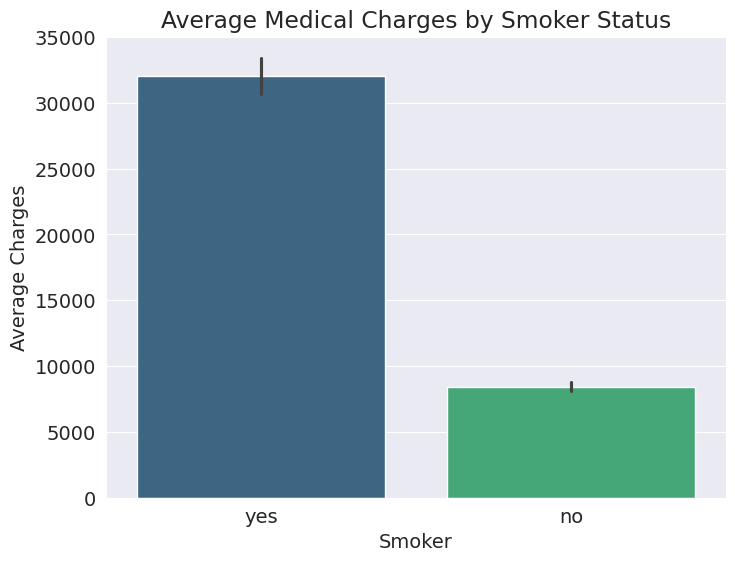

In [39]:

# Smoker vs. Charges (Bar Plot) - using seaborn
plt.figure(figsize=(8, 6))
sns.barplot(x='smoker', y='charges', data=medical_df, palette='viridis', hue='smoker', legend=False)
plt.title('Average Medical Charges by Smoker Status')
plt.ylabel('Average Charges')
plt.xlabel('Smoker')
plt.show()

### Inferences from Visualizations:

Based on the recently generated violin and bar plots, we can draw the following conclusions regarding medical charges and other factors:

*   **Children vs. Charges**: The violin plot for 'children' shows that while the median charges do not drastically increase with the number of children, there is a tendency for higher charges and a wider spread, particularly at higher numbers of children, suggesting that having more dependents might correlate with higher potential medical costs, possibly due to a family's overall health needs.

*   **Sex vs. Charges**: Similar to earlier observations, the violin plot for 'sex' confirms that the distribution of medical charges between males and females is quite comparable. Both groups exhibit similar median charges and spread, indicating that 'sex' alone is not a primary driver of significant differences in medical expenses.

*   **Region vs. Charges**: The 'region' violin plots illustrate that medical charges are distributed similarly across all four regions (northeast, northwest, southeast, southwest). No single region displays a significantly higher or lower charge distribution compared to others, suggesting that geographical region, by itself, may not be a strong independent predictor of medical costs.

*   **Smoker vs. Charges**: The bar plot distinctly highlights that 'smoker' status is a paramount factor influencing medical charges. Smokers consistently incur substantially higher average medical charges compared to non-smokers. This emphasizes that smoking habits are a critical determinant of medical expenses in this dataset.

---

### Correlation

As you can tell from the analysis, the values in some columns are more closely related to the values in "charges" compared to other columns. E.g. "age" and "charges" seem to grow together, whereas "bmi" and "charges" don't.

This relationship is often expressed numerically using a measure called the _correlation coefficient_, which can be computed using the `.corr` method of a Pandas series.

In [40]:
medical_df.charges.corr(medical_df.age) # Calculate the correlation coefficient between 'charges' and 'age'

np.float64(0.2990081933306476)

In [41]:
medical_df.charges.corr(medical_df.bmi)

np.float64(0.19834096883362895)

In [42]:
# To compute the correlation for categorical columns, they must first be converted into numeric columns.
smoker_values = {'no': 0, 'yes': 1}
smoker_numeric = medical_df.smoker.map(smoker_values)
medical_df['smoker_numeric']=medical_df.smoker.map(smoker_values)
medical_df.charges.corr(smoker_numeric)

np.float64(0.787251430498478)

In [43]:
medical_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             1338 non-null   int64  
 1   sex             1338 non-null   object 
 2   bmi             1338 non-null   float64
 3   children        1338 non-null   int64  
 4   smoker          1338 non-null   object 
 5   region          1338 non-null   object 
 6   charges         1338 non-null   float64
 7   smoker_numeric  1338 non-null   int64  
dtypes: float64(2), int64(3), object(3)
memory usage: 83.8+ KB


* **Strength**: The greater the absolute value of the correlation coefficient, the stronger the relationship.

    * The extreme values of -1 and 1 indicate a perfectly linear relationship where a change in one variable is accompanied by a perfectly consistent change in the other. For these relationships, all of the data points fall on a line. In practice, you won’t see either type of perfect relationship.

    * A coefficient of zero represents no linear relationship. As one variable increases, there is no tendency in the other variable to either increase or decrease.
    
    * When the value is in-between 0 and +1/-1, there is a relationship, but the points don’t all fall on a line. As r approaches -1 or 1, the strength of the relationship increases and the data points tend to fall closer to a line.


* **Direction**: The sign of the correlation coefficient represents the direction of the relationship.

    * Positive coefficients indicate that when the value of one variable increases, the value of the other variable also tends to increase. Positive relationships produce an upward slope on a scatterplot.
    
    * Negative coefficients represent cases when the value of one variable increases, the value of the other variable tends to decrease. Negative relationships produce a downward slope.

Here's the same relationship expressed visually ([source](https://www.cuemath.com/data/how-to-calculate-correlation-coefficient/)):

<img src="https://i.imgur.com/3XUpDlw.png" width="360">

The correlation coefficient has the following formula:

<img src="https://i.imgur.com/unapugP.png" width="360">


Pandas dataframes also provide a `.corr` method to compute the correlation coefficients between all pairs of numeric columns.

In [44]:
medical_df.select_dtypes(include=['float64', 'int64',]).corr()

,age,bmi,children,charges,smoker_numeric
age,1.000000,0.109272,0.042469,0.299008,-0.025019
bmi,0.109272,1.000000,0.012759,0.198341,0.003750
children,0.042469,0.012759,1.000000,0.067998,0.007673
charges,0.299008,0.198341,0.067998,1.000000,0.787251
smoker_numeric,-0.025019,0.003750,0.007673,0.787251,1.000000


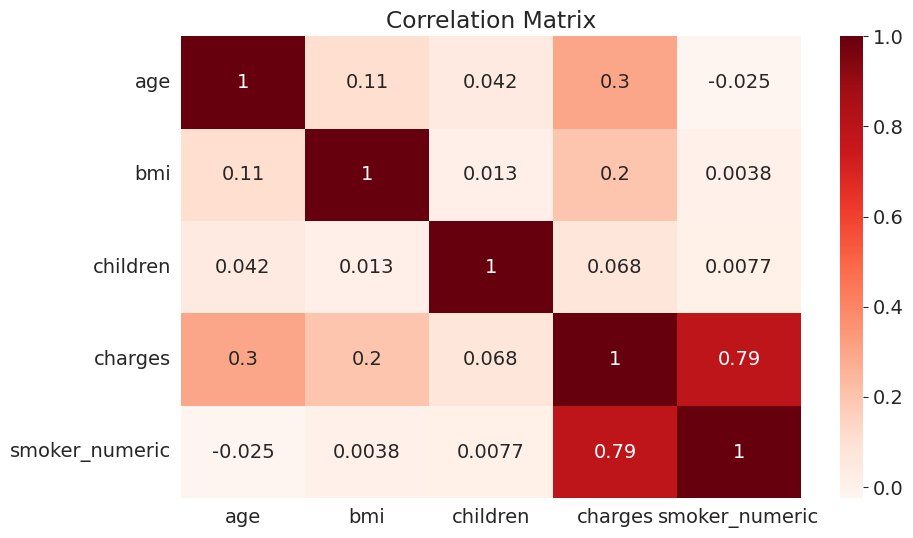

In [45]:
sns.heatmap(medical_df.select_dtypes(include=['float64', 'int64']).corr(), cmap='Reds', annot=True)
plt.title('Correlation Matrix');

**Correlation vs causation fallacy:** Note that a high correlation cannot be used to interpret a cause-effect relationship between features. Two features $X$ and $Y$ can be correlated if $X$ causes $Y$ or if $Y$ causes $X$, or if both are caused independently by some other factor $Z$, and the correlation will no longer hold true if one of the cause-effect relationships is broken. It's also possible that $X$ are $Y$ simply appear to be correlated because the sample is too small.

While this may seem obvious, computers can't differentiate between correlation and causation, and decisions based on automated system can often have major consequences on society, so it's important to study why automated systems lead to a given result. Determining cause-effect relationships requires human insight.

---

## Linear Regression using a Single Feature

We now know that the "smoker" and "age" columns have the strongest correlation with "charges". Let's try to find a way of estimating the value of "charges" using the value of "age" for non-smokers. First, let's create a data frame containing just the data for non-smokers.

In [46]:
non_smoker_df = medical_df[medical_df.smoker == 'no'] # Create a new DataFrame containing only non-smoker data

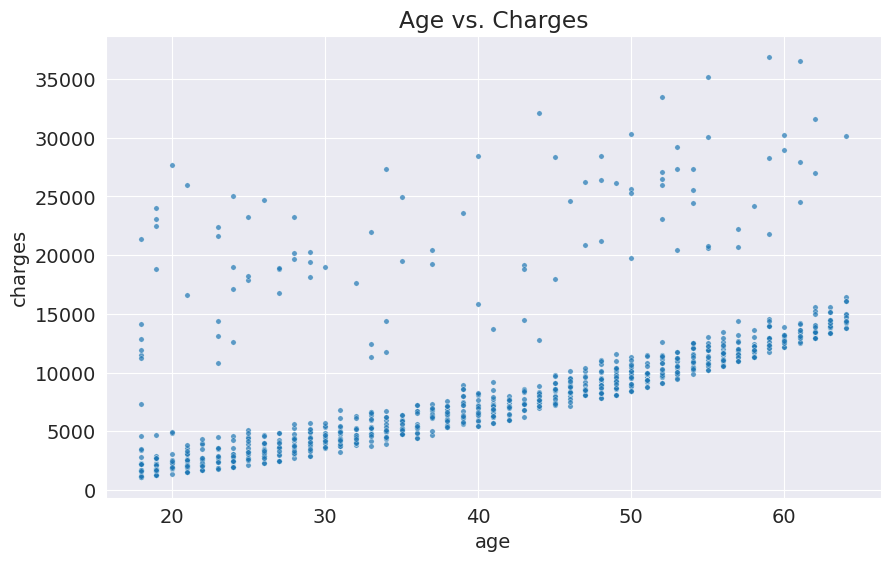

In [47]:
plt.title('Age vs. Charges')
sns.scatterplot(data=non_smoker_df, x='age', y='charges', alpha=0.7, s=15);

Apart from a few exceptions, the points seem to form a line. We'll try and "fit" a line using this points, and use the line to predict charges for a given age. A line on the X&Y coordinates has the following formula:

$y = wx + b$

The line is characterized two numbers: $w$ (called "slope") and $b$ (called "intercept").

### Model

In the above case, the x axis shows "age"(Independent) and the y axis shows "charges" (Dependent). Thus, we're assume the following relationship between the two:

$charges = w \times age + b$

We'll try determine $w$ and $b$ for the line that best fits the data.

* This technique is called _linear regression_, and we call the above equation a _linear regression model_, because it models the relationship between "age" and "charges" as a straight line.

* The numbers $w$ and $b$ are called the _parameters_ or _weights_ of the model.

* The values in the "age" column of the dataset are called the _inputs_ to the model and the values in the charges column are called "targets".

Let define a helper function `estimate_charges`, to compute $charges$, given $age$, $w$ and $b$.

In [48]:
def estimate_charges(age, w, b):
    return w * age + b

The `estimate_charges` function is our very first _model_.

Let's _guess_ the values for $w$ and $b$ and use them to estimate the value for charges.

In [49]:
w = 50
b = 100

Text(0, 0.5, 'Charges')

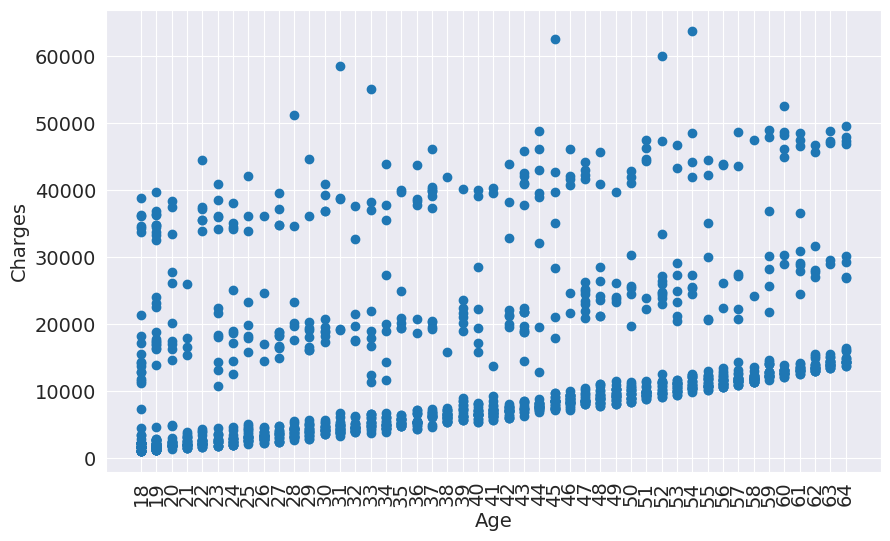

In [50]:
plt.scatter(medical_df['age'], medical_df['charges'])
plt.xticks(range(int(medical_df['age'].min()), int(medical_df['age'].max()) + 1, 1), rotation=90)
# Set x-axis ticks for each age from min to max, and rotate labels by 90 degrees for readability.
plt.xlabel('Age')
plt.ylabel('Charges')

In [51]:
ages=medical_df['age']
mean_charges_by_age = medical_df.groupby('age')['charges'].mean()
sorted_age=ages.drop_duplicates().sort_values() # Get unique ages and sort them for a clean printout
estimated_charges = estimate_charges(sorted_age, w, b) # Estimate charges using the 'estimate_charges' function with guessed 'w' and 'b'
print(f"{'Age':<5}{'Est. Charges':<15}{'Actual Charges':<18}{'|Error|':<15}") # Print header for the output table
for i, j, k in zip(sorted_age, estimated_charges, mean_charges_by_age): # Iterate through sorted unique ages and their corresponding estimated charges
    off_by=k-j # Calculate the difference between actual and estimated charges
    # The ':<5' format specifier left-aligns the content within a field of minimum width 5 characters.
    # For example, '{i:<5}' will print the value of 'i' and pad it with spaces on the right until it takes up at least 5 characters.
    print(f"{i:<5}{j:<15}{k:<18.2f}{off_by:<15.2f}")

Age  Est. Charges   Actual Charges    |Error|        
18   1000           7086.22           6086.22        
19   1050           9747.91           8697.91        
20   1100           10159.70          9059.70        
21   1150           4730.46           3580.46        
22   1200           10012.93          8812.93        
23   1250           12419.82          11169.82       
24   1300           10648.02          9348.02        
25   1350           9838.37           8488.37        
26   1400           6133.83           4733.83        
27   1450           12184.70          10734.70       
28   1500           9069.19           7569.19        
29   1550           10430.16          8880.16        
30   1600           12719.11          11119.11       
31   1650           10196.98          8546.98        
32   1700           9220.30           7520.30        
33   1750           12351.53          10601.53       
34   1800           11613.53          9813.53        
35   1850           11307.18

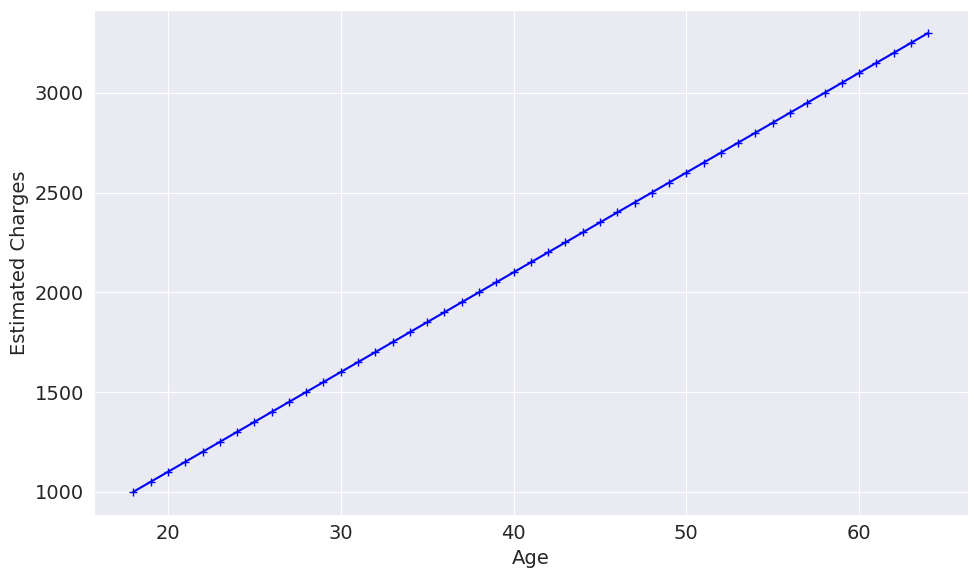

In [52]:
plt.plot(sorted_age, estimated_charges, 'b-+'); # 'r-o' specifies red color ('r'), solid line ('-'), and circle markers ('o')
plt.xlabel('Age')
plt.ylabel('Estimated Charges')
plt.tight_layout()
plt.show()

As expected, the points lie on a straight line.

We can overlay this line on the actual data, so see how well our _model_ fits the _data_.

In [53]:
ages.shape

(1338,)

In [54]:
estimated_charges.shape

(47,)

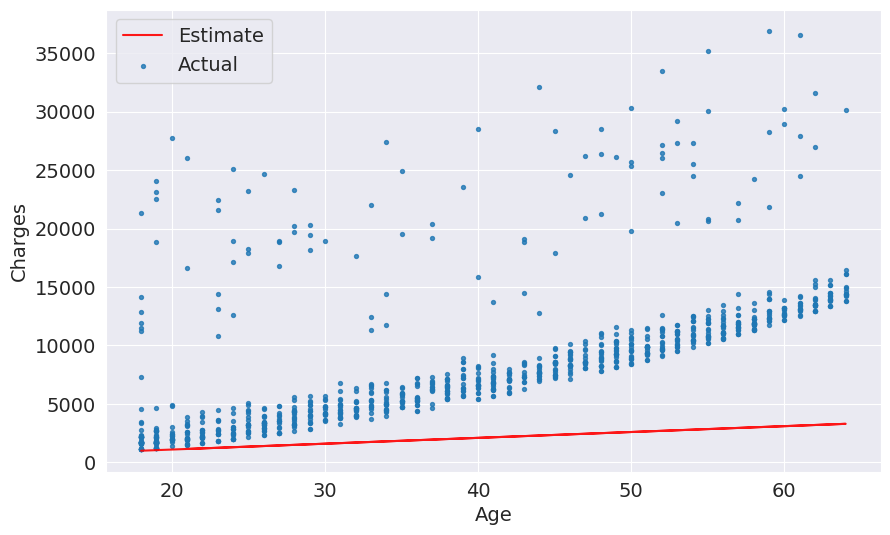

In [55]:
ages_non_smoker = non_smoker_df.age
target_non_smoker = non_smoker_df.charges

# Recalculate estimated_charges for all non-smoker ages using the current w and b
estimated_charges_for_plot = estimate_charges(ages_non_smoker, w, b)

plt.plot(ages_non_smoker, estimated_charges_for_plot, 'r', alpha=0.9);
plt.scatter(ages_non_smoker, target_non_smoker, s=8,alpha=0.8);
plt.xlabel('Age');
plt.ylabel('Charges')
plt.legend(['Estimate', 'Actual']);

Clearly, the our estimates are quite poor and the line does not "fit" the data. However, we can try different values of $w$ and $b$ to move the line around. Let's define a helper function `try_parameters` which takes `w` and `b` as inputs and creates the above plot.

In [56]:
def try_parameters(w, b):
    ages = non_smoker_df.age
    target = non_smoker_df.charges

    estimated_charges = estimate_charges(ages, w, b)

    plt.plot(ages, estimated_charges, 'r', alpha=0.9);
    plt.scatter(ages, target, s=8,alpha=0.8);
    plt.xlabel('Age');
    plt.ylabel('Charges')
    plt.legend(['Estimate', 'Actual']);

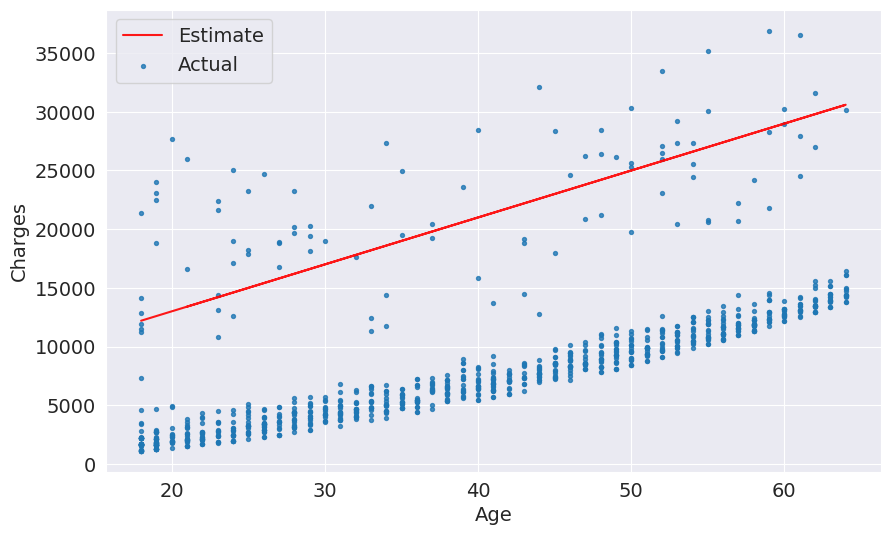

In [57]:

try_parameters(400, 5000)

As we change the values, of $w$ and $b$ manually, trying to move the line visually closer to the points, we are _learning_ the approximate relationship between "age" and "charges".

Wouldn't it be nice if a computer could try several different values of `w` and `b` and _learn_ the relationship between "age" and "charges"? To do this, we need to solve a couple of problems:

1. We need a way to measure numerically how well the line fits the points.

2. Once the "measure of fit" has been computed, we need a way to modify `w` and `b` to improve the the fit.

If we can solve the above problems, it should be possible for a computer to determine `w` and `b` for the best fit line, starting from a random guess.

### Loss/Cost Function

We can compare our model's predictions with the actual targets using the following method:

* Calculate the difference between the targets and predictions (the differenced is called the "residual")
* Square all elements of the difference matrix to remove negative values.
* Calculate the average of the elements in the resulting matrix.
* Take the square root of the result

The result is a single number, known as the **root mean squared error** (RMSE). The above description can be stated mathematically as follows:

<img src="https://i.imgur.com/WCanPkA.png" width="360">

Geometrically, the residuals can be visualized as follows:

<img src="https://i.imgur.com/ll3NL80.png" width="420">

Let's define a function to compute the RMSE.

In [58]:
def rmse(targets, predictions):
    return np.sqrt(np.mean(np.square(targets - predictions)))

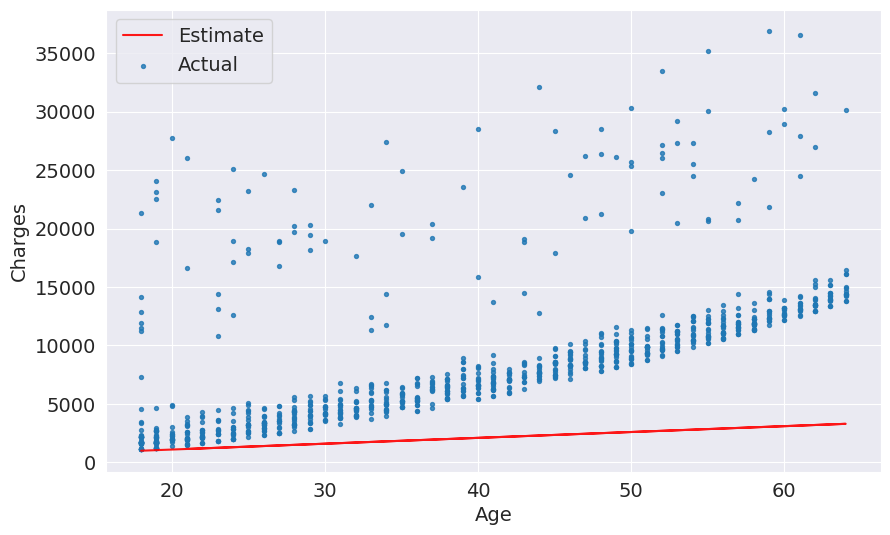

In [59]:
# Let's compute the RMSE for our model with a sample set of weights
w = 50
b = 100
try_parameters(w, b)

In [60]:
targets = non_smoker_df['charges']
predicted = estimate_charges(non_smoker_df.age, w, b)

In [61]:
rmse(targets, predicted)

np.float64(8461.949562575493)

Here's how we can interpret the above number: *On average, each element in the prediction differs from the actual target by \\$8461*.

The result is called the *loss* because it indicates how bad the model is at predicting the target variables. It represents information loss in the model: the lower the loss, the better the model.

Let's modify the `try_parameters` functions to also display the loss.

In [62]:
def try_parameters(w, b):
    ages = non_smoker_df.age
    target = non_smoker_df.charges
    # Explanation of column access methods:
    # 1. `non_smoker_df.age` (attribute-style access): This is a convenient shorthand
    #    for accessing columns when the column name is a valid Python identifier
    #    (i.e., no spaces, special characters, or names that conflict with DataFrame methods).
    #    It returns a Pandas Series.
    #
    # 2. `non_smoker_df.charges` (attribute-style access): Similar to `non_smoker_df.age`,
    #    this is a convenient way to get the 'charges' column as a Series.
    #
    # 3. `non_smoker_df['charges']` (dictionary-style access): This is the more robust and
    #    recommended way to access columns. It uses square brackets with the column name
    #    as a string. This method works universally, even if column names contain spaces,
    #    special characters, or are stored in variables. It also returns a Pandas Series.
    #
    # If you used `non_smoker_df[charges]` where `charges` was a variable name
    # and not a string literal like `'charges'`, it would result in a NameError
    # unless a variable named 'charges' holding the string 'charges' was defined.
    # Both `non_smoker_df.charges` and `non_smoker_df['charges']` are equivalent
    # when 'charges' is a simple column name without special characters.
    predictions = estimate_charges(ages, w, b)

    plt.plot(ages, predictions, 'r', alpha=0.9);
    plt.scatter(ages, target, s=8,alpha=0.8);
    plt.xlabel('Age');
    plt.ylabel('Charges')
    plt.legend(['Prediction', 'Actual']);

    loss = rmse(target, predictions)
    print("RMSE Loss: ", loss)

RMSE Loss:  8461.949562575493


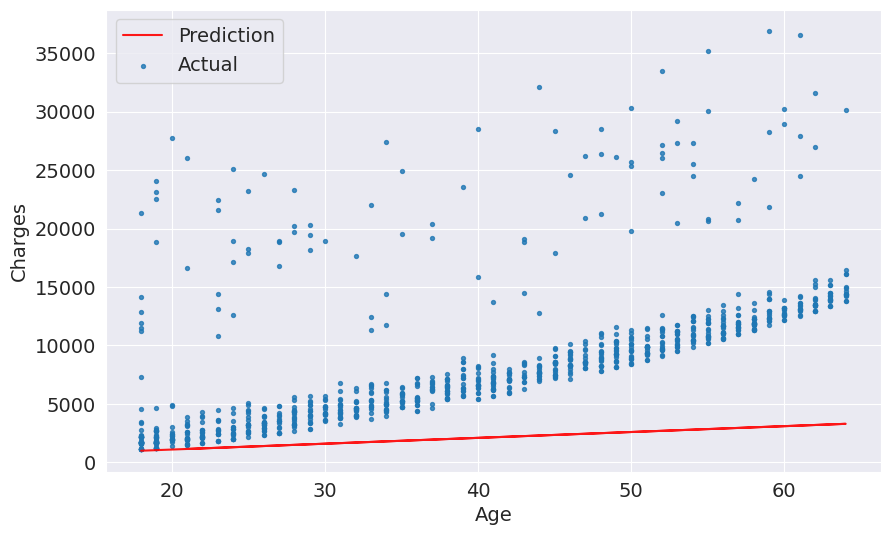

In [63]:
try_parameters(50, 100)

### Optimizer

Next, we need a strategy to modify weights `w` and `b` to reduce the loss and improve the "fit" of the line to the data.

* Ordinary Least Squares: https://www.youtube.com/watch?v=szXbuO3bVRk (better for smaller datasets)
* Stochastic gradient descent: https://www.youtube.com/watch?v=sDv4f4s2SB8 (better for larger datasets)

Both of these have the same objective: to minimize the loss, however, while ordinary least squares directly computes the best values for `w` and `b` using matrix operations, while gradient descent uses a iterative approach, starting with a random values of `w` and `b` and slowly improving them using derivatives.

Here's a visualization of how gradient descent works:

![](https://miro.medium.com/max/1728/1*NO-YvpHHadk5lLxtg4Gfrw.gif)

Doesn't it look similar to our own strategy of gradually moving the line closer to the points?


# Linear Regression using Scikit-Learn

In [64]:
from sklearn.linear_model import LinearRegression

# Sparse Matrix
A sparse matrix is a 2D array, or matrix, containing a high proportion of zero elements compared to non-zero elements

In [65]:
# Select 'age' as the input feature. Using double square brackets `[['age']]` ensures
# that `inputs` is a Pandas DataFrame (2D structure), which is the standard expected format
# for input features (X) by scikit-learn models, even when there's only one feature.
inputs = non_smoker_df[['age']]

# Select 'charges' as the target variable. Using single square brackets `['charges']`
# results in a Pandas Series (1D structure), which is the standard expected format
# for the target variable (y) by scikit-learn models.
targets = non_smoker_df['charges']

print('inputs.shape :', inputs.shape)
print('targes.shape :', targets.shape)

inputs.shape : (1064, 1)
targes.shape : (1064,)


In [66]:
# Let's fit the model to the data.
model = LinearRegression()


In [67]:
model.fit(inputs, targets)

LinearRegression()

We can now make predictions using the model. Let's try predicting the charges for the ages 23, 37 and 61

In [68]:
model.predict(np.array([[23],
                        [37],
                        [61]]))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



array([ 4055.30443855,  7796.78921819, 14210.76312614])

In [69]:
predictions = model.predict(inputs)

In [70]:
inputs

,age
1,18
2,28
3,33
4,32
5,31
...,...
1332,52
1333,50
1334,18
1335,18


In [71]:
predictions

array([2719.0598744 , 5391.54900271, 6727.79356686, ..., 2719.0598744 ,
       2719.0598744 , 3520.80661289])

In [72]:
targets

,charges
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520
5,3756.62160
...,...
1332,11411.68500
1333,10600.54830
1334,2205.98080
1335,1629.83350


In [73]:
print(targets.shape,'\n',predictions.flatten().shape)

(1064,) 
 (1064,)


In [74]:
rmse(targets, predictions.flatten())
# The `predictions` array, generated by `model.predict(inputs)`, has a shape of (1064, 1),
# meaning it's a 2D array (a column vector). However, the `targets` (medical charges)
# are a Pandas Series with a shape of (1064,), which is 1-dimensional.
#
# To perform element-wise operations (like subtraction for RMSE calculation) between `targets`
# and `predictions`, both arrays must have compatible dimensions. Subtracting a (1064,) Series
# from a (1064, 1) array directly would lead to a broadcasting error (or an unexpected (1064, 1064) result).
#
# Therefore, `.flatten()` is used here to convert the `predictions` array from its 2D shape (1064, 1)
# into a 1D array with a shape of (1064,). This makes it compatible with the `targets` Series,
# allowing the `rmse` function to correctly calculate the root mean squared error.

np.float64(4662.505766636395)

Seems like our prediction is off by $4000 on average, which is not too bad considering the fact that there are several outliers.

In [75]:
# w
model.coef_

array([267.24891283])

In [76]:
# b
model.intercept_

np.float64(-2091.4205565650864)

RMSE Loss:  4662.505766636395


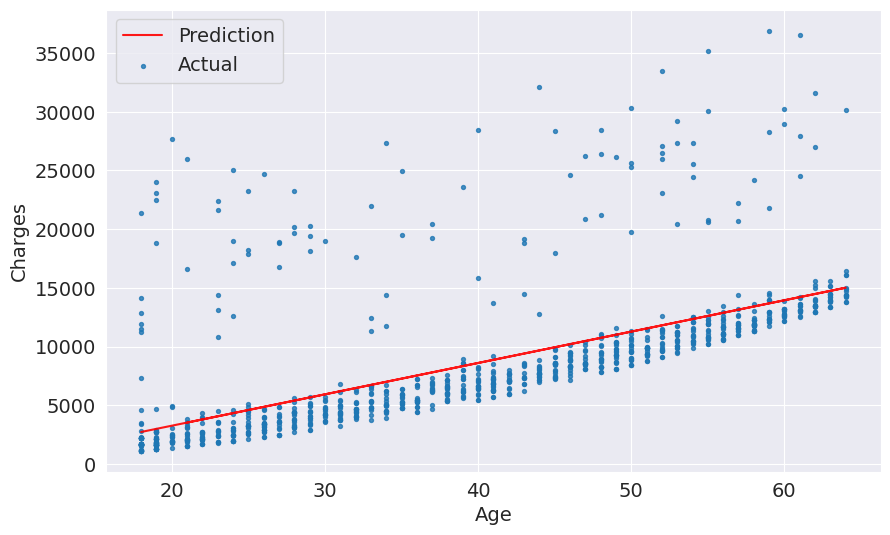

In [77]:
try_parameters(model.coef_, model.intercept_)

Indeed the line is quite close to the points. It is slightly above the cluster of points, because it's also trying to account for the outliers.



SGDRegressor RMSE Loss: 4950.755108149788
LinearRegression RMSE Loss: 4662.505766636395


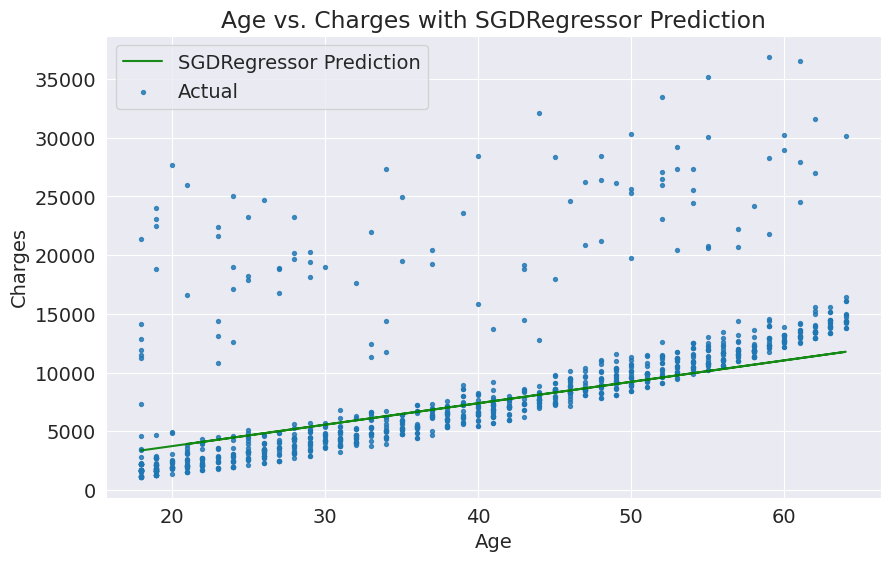

In [78]:
from sklearn.linear_model import SGDRegressor

# Initialize the SGDRegressor model
# SGDRegressor uses Stochastic Gradient Descent to estimate the coefficients.
# random_state=42 ensures reproducibility of the results.
# max_iter=1000 sets the maximum number of passes over the training data (epochs).
# tol=1e-3 (tolerance) is a stopping criterion; the optimization will stop when the loss
# does not improve by at least tol for n_iter_no_change consecutive epochs.
sgd_model = SGDRegressor(random_state=42, max_iter=1000, tol=1e-3)

# Fit the SGDRegressor model to the data
# 'inputs' (age) are the features, and 'targets' (charges) are the labels.
# The model learns the optimal weights (coefficients) and intercept through iteration.
sgd_model.fit(inputs, targets)

# Make predictions using the trained SGDRegressor model
# The predict method returns the estimated charges based on the input ages.
sgd_predictions = sgd_model.predict(inputs)

# Compute the RMSE loss for the SGDRegressor predictions
# We use .flatten() to convert the predictions array from (N, 1) to (N,) to match the target's shape
# for accurate element-wise comparison in the RMSE function.
sgd_loss = rmse(targets, sgd_predictions.flatten())

print(f"SGDRegressor RMSE Loss: {sgd_loss}")

# Compare the RMSE of SGDRegressor with the previously calculated LinearRegression RMSE
print(f"LinearRegression RMSE Loss: {rmse(targets, predictions.flatten())}")

# Plot the results of the SGDRegressor model
plt.figure(figsize=(10, 6))
# Plot the SGDRegressor's prediction line in green
plt.plot(non_smoker_df.age, sgd_predictions, 'g', alpha=0.9, label='SGDRegressor Prediction');
# Plot the actual data points as a scatter plot
plt.scatter(non_smoker_df.age, non_smoker_df.charges, s=8, alpha=0.8, label='Actual');
plt.xlabel('Age');
plt.ylabel('Charges')
plt.legend();
plt.title('Age vs. Charges with SGDRegressor Prediction');
plt.show()

### Machine Learning

Machine learning is simply the process of computing the best parameters to model the relationship between some feature and targets.

Every machine learning problem has three components:

1. **Model**

2. **Cost Function**

3. **Optimizer**


<img src="https://www.deepnetts.com/blog/wp-content/uploads/2019/02/SupervisedLearning.png" width="480">

## Linear Regression using Multiple Features

So far, we've used on the "age" feature to estimate "charges". Adding another feature like "bmi" is fairly straightforward. We simply assume the following relationship:

$charges = w_1 \times age + w_2 \times bmi + b$



In [79]:
# Create inputs and targets
inputs, targets = non_smoker_df[['age', 'bmi']], non_smoker_df['charges']

# Create and train the model
model = LinearRegression().fit(inputs, targets)

# Generate predictions
predictions = model.predict(inputs)

# Compute loss to evalute the model
loss = rmse(targets, predictions)
print('Loss:', loss)

Loss: 4662.3128354612945


Adding the BMI doesn't seem to reduce the loss by much, as the BMI has a very weak correlation with charges, especially for non smokers.

In [80]:
model.coef_, model.intercept_

(array([266.87657817,   7.07547666]), np.float64(-2293.6320906488727))

In [81]:
non_smoker_df.charges.corr(non_smoker_df.bmi)

np.float64(0.0840365431283327)

In [82]:
fig = px.scatter(non_smoker_df, x='bmi', y='charges', title='BMI vs. Charges')
fig.update_traces(marker_size=5)
fig.show()

Let's go one step further, and add the final numeric column: "children", which seems to have some correlation with "charges".

$charges = w_1 \times age + w_2 \times bmi + w_3 \times charges + b$

In [83]:
non_smoker_df.charges.corr(non_smoker_df.children)

np.float64(0.13892870453542192)

In [84]:
fig = px.strip(non_smoker_df, x='children', y='charges', title= "Children vs. Charges")
# `fig.update_traces` is used to update the properties of the traces (data series) within the figure.
# Here, it's used to customize the appearance of the markers in the strip plot.
# `marker_size=4`: Sets the size of each data point marker to 4 pixels, making them smaller.
# `marker_opacity=0.7`: Sets the transparency of the markers to 70%. This is useful for dense plots
#                       where overlapping points can obscure visibility, allowing underlying points to be seen.
fig.update_traces(marker_size=4, marker_opacity=0.7)
fig.show()

In [85]:
# Create inputs and targets
inputs, targets = non_smoker_df[['age', 'bmi', 'children']], non_smoker_df['charges']

# Create and train the model
model = LinearRegression().fit(inputs, targets)

# Generate predictions
predictions = model.predict(inputs)

# Compute loss to evalute the model
loss = rmse(targets, predictions)
print('Loss:', loss)

Loss: 4608.470405038247


Once again, we don't see a big reduction in the loss, even though it's greater than in the case of BMI.

Inputs shape: (1338, 3)
Targets shape: (1338,)

RMSE Loss for all customers: 11355.317901125973
RMSE Loss for non-smokers only: 4608.470405038247


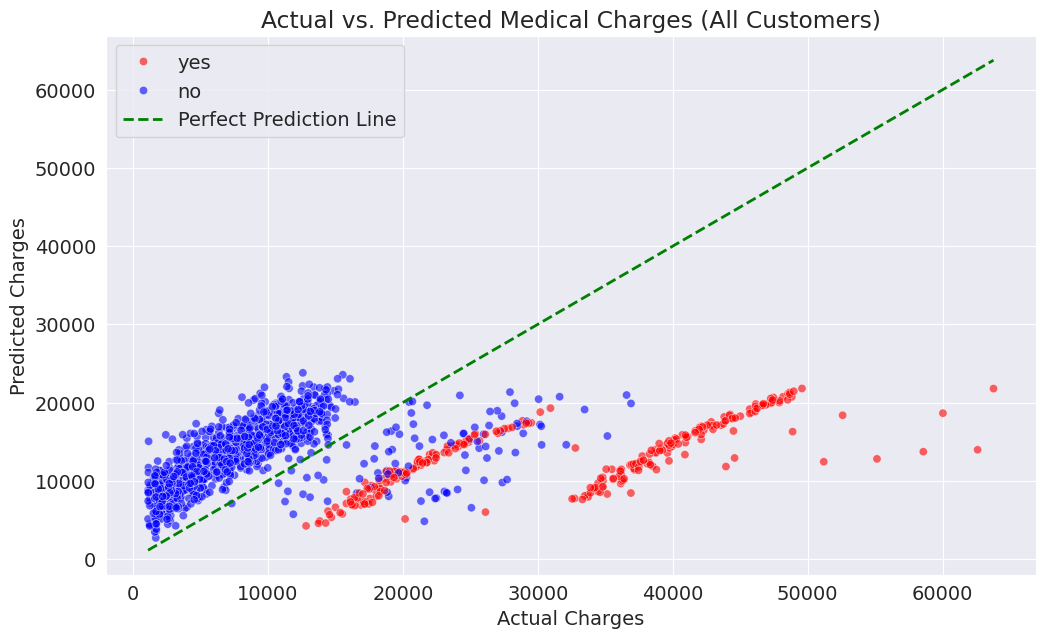

In [86]:
# 1. Prepare inputs and targets for all customers
# We'll use 'age', 'bmi', 'children', and 'smoker_numeric' as input features.
inputs_all = medical_df[['age', 'bmi', 'children']]
targets_all = medical_df['charges']

print(f"Inputs shape: {inputs_all.shape}")
print(f"Targets shape: {targets_all.shape}")

# 2. Train a Linear Regression model
model_all = LinearRegression()
model_all.fit(inputs_all, targets_all)

# 3. Make predictions
predictions_all = model_all.predict(inputs_all)

# 4. Compute the loss (RMSE)
loss_all = rmse(targets_all, predictions_all)
print(f"\nRMSE Loss for all customers: {loss_all}")

# Compare with non-smoker model loss
print(f"RMSE Loss for non-smokers only: {loss}") # 'loss' variable from previous cell

# 5. Visualize targets and predictions
plt.figure(figsize=(12, 7))
sns.scatterplot(x=targets_all, y=predictions_all, alpha=0.6, hue=medical_df['smoker'], palette={'yes': 'red', 'no': 'blue'})
plt.plot([min(targets_all), max(targets_all)], [min(targets_all), max(targets_all)], color='green', linestyle='--', lw=2, label='Perfect Prediction Line')
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Actual vs. Predicted Medical Charges (All Customers)')
plt.legend()
plt.grid(True)
plt.show()



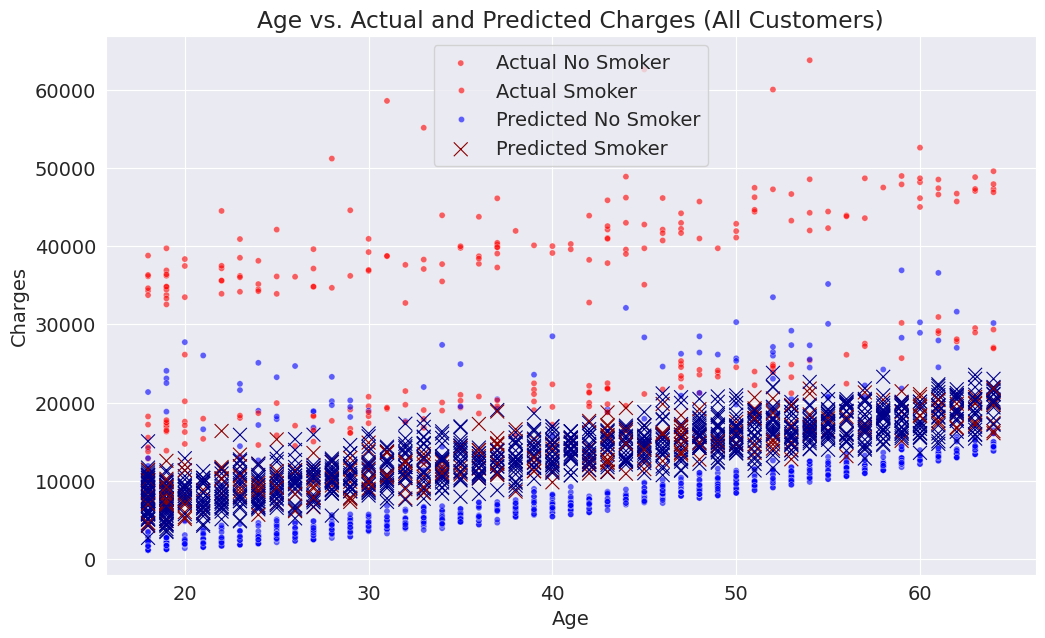

In [87]:
# Another visualization: Age vs. Charges with predictions, separated by smoker status
plt.figure(figsize=(12, 7))
sns.scatterplot(data=medical_df, x='age', y='charges', hue='smoker', alpha=0.6, s=20, palette={'yes': 'red', 'no': 'blue'}) # Removed 'label' argument
sns.scatterplot(x=medical_df['age'], y=predictions_all, hue=medical_df['smoker'], marker='x', s=100, palette={'yes': 'darkred', 'no': 'darkblue'}, legend=False, label='Predicted Charges')
plt.xlabel('Age')
plt.ylabel('Charges')
plt.title('Age vs. Actual and Predicted Charges (All Customers)')
plt.legend(['Actual No Smoker', 'Actual Smoker', 'Predicted No Smoker', 'Predicted Smoker'])
plt.grid(True)
plt.show()

## Using Categorical Features for Machine Learning

So far we've been using only numeric columns, since we can only perform computations with numbers. If we could use categorical columns like "smoker", we can train a single model for the entire dataset.

To use the categorical columns, we simply need to convert them to numbers. There are three common techniques for doing this:

1. If a categorical column has just two categories (it's called a binary category), then we can replace their values with 0 and 1.
2. If a categorical column has more than 2 categories, we can perform one-hot encoding i.e. create a new column for each category with 1s and 0s.
3. If the categories have a natural order (e.g. cold, neutral, warm, hot), then they can be converted to numbers (e.g. 1, 2, 3, 4) preserving the order. These are called ordinals



In [88]:
smoker_codes = {'no': 0, 'yes': 1}
medical_df['smoker_code'] = medical_df.smoker.map(smoker_codes)

In [89]:
medical_df.charges.corr(medical_df.smoker_code)

np.float64(0.787251430498478)

In [92]:
medical_df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges',
       'smoker_numeric', 'smoker_code'],
      dtype='object')

We can now use the `smoker_codes` column for linear regression.

$charges = w_1 \times age + w_2 \times bmi + w_3 \times charges + w_4 \times smoker + b$

In [94]:
# Create inputs and targets
inputs, targets = medical_df[['age', 'bmi', 'children', 'smoker_code']], medical_df['charges']

# Create and train the model
model = LinearRegression().fit(inputs, targets)

# Generate predictions
predictions = model.predict(inputs)

# Compute loss to evalute the model
loss = rmse(targets, predictions)
print('Loss:', loss)

Loss: 6056.439217188081


The loss reduces from `11355` to `6056`, almost by 50%! This is an important lesson: never ignore categorical data.


Let's try adding the "sex" column as well.

$charges = w_1 \times age + w_2 \times bmi + w_3 \times charges + w_4 \times smoker + w_5 \times sex + b$

<Axes: xlabel='sex', ylabel='charges'>

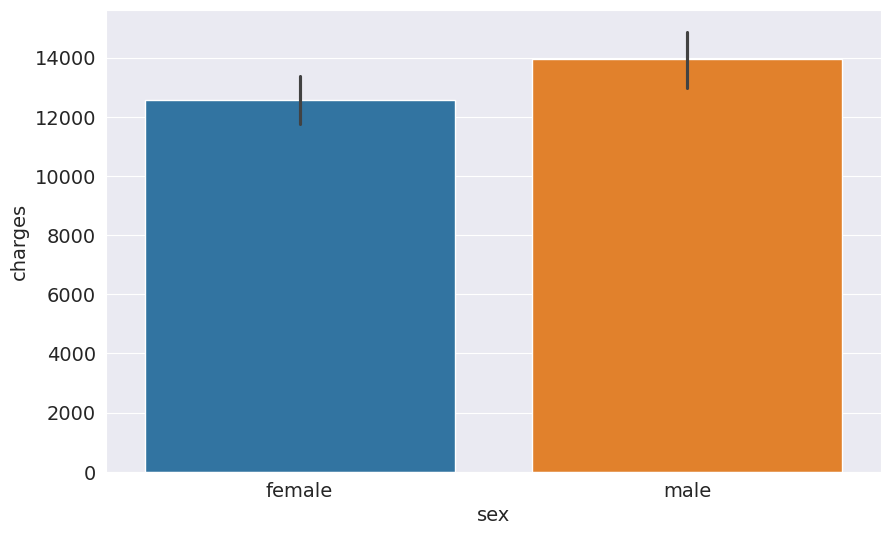

In [99]:
sns.barplot(data=medical_df, x='sex', y='charges', hue='sex')

In [100]:
sex_codes = {'female': 0, 'male': 1}
medical_df['sex_code'] = medical_df.sex.map(sex_codes)
medical_df.charges.corr(medical_df.sex_code)

np.float64(0.057292062202025484)

In [101]:
# Create inputs and targets
inputs, targets = medical_df[['age', 'bmi', 'children', 'smoker_code', 'sex_code']], medical_df['charges']

# Create and train the model
model = LinearRegression().fit(inputs, targets)

# Generate predictions
predictions = model.predict(inputs)

# Compute loss to evalute the model
loss = rmse(targets, predictions)
print('Loss:', loss)

Loss: 6056.100708754546



### One-hot Encoding

The "region" column contains 4 values, so we'll need to use hot encoding and create a new column for each region.

![](https://i.imgur.com/n8GuiOO.png)

/tmp/ipykernel_463/824967832.py:1: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




<Axes: xlabel='region', ylabel='charges'>

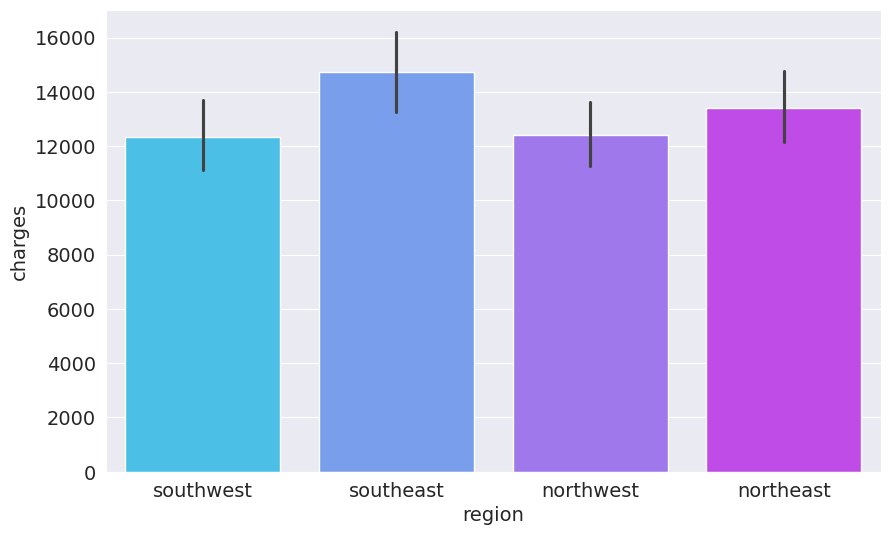

In [105]:
sns.barplot(data=medical_df, x='region', y='charges', palette='cool')

In [127]:
from sklearn.preprocessing import OneHotEncoder
enc = OneHotEncoder() # Create an instance of OneHotEncoder
enc.fit_transform(medical_df[['region']]) # Then call fit on the instance

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1336 stored elements and shape (1336, 4)>

In [128]:
one_hot = enc.transform(medical_df[['region']]).toarray()
one_hot

array([[0., 0., 1., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       ...,
       [0., 0., 1., 0.],
       [0., 0., 0., 1.],
       [0., 1., 0., 0.]])

In [130]:
medical_df[['NE','NW','SE','SW']]=one_hot

In [131]:
medical_df

,age,sex,bmi,children,smoker,region,charges,smoker_code,sex_code,NE,NW,SE,SW
2,28,male,33.000,3,no,southeast,4449.46200,0,1,0.0,0.0,1.0,0.0
3,33,male,22.705,0,no,northwest,21984.47061,0,1,0.0,1.0,0.0,0.0
4,32,male,28.880,0,no,northwest,3866.85520,0,1,0.0,1.0,0.0,0.0
5,31,female,25.740,0,no,southeast,3756.62160,0,0,0.0,0.0,1.0,0.0
6,46,female,33.440,1,no,southeast,8240.58960,0,0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,0,1,0.0,1.0,0.0,0.0
1334,18,female,31.920,0,no,northeast,2205.98080,0,0,1.0,0.0,0.0,0.0
1335,18,female,36.850,0,no,southeast,1629.83350,0,0,0.0,0.0,1.0,0.0
1336,21,female,25.800,0,no,southwest,2007.94500,0,0,0.0,0.0,0.0,1.0


Let's include the region columns into our linear regression model.

$charges = w_1 \times age + w_2 \times bmi + w_3 \times charges + w_4 \times smoker + w_5 \times sex + w_n \times region + b$

In [133]:
# Create inputs and targets
input_cols = ['age', 'bmi', 'children', 'smoker_code', 'sex_code', 'NE', 'NW', 'SE', 'SW']
inputs, targets = medical_df[input_cols], medical_df['charges']

# Create and train the model
model = LinearRegression().fit(inputs, targets)

# Generate predictions
predictions = model.predict(inputs)

# Compute loss to evalute the model
loss = rmse(targets, predictions)
print('Loss:', loss)

Loss: 6041.596128074733


## Model Improvements

Let's discuss and apply some more improvements to our model.

### Feature Scaling

Recall that due to regulatory requirements, we also need to explain the rationale behind the predictions our model.

$charges = w_1 \times age + w_2 \times bmi + w_3 \times charges + w_4 \times smoker + w_5 \times sex + w_6 \times region + b$

To compare the importance of each feature in the model, our first instinct might be to compare their weights.

In [134]:
model.coef_

array([  256.09910173,   339.01322597,   470.83531133, 23879.3260965 ,
        -143.57001695,   578.72097045,   226.95851857,  -452.16093807,
        -353.51855094])

In [135]:
model.intercept_

np.float64(-12477.586074955456)

In [139]:
weights_df = pd.DataFrame({
    'feature': np.append(input_cols, 1), # 'feature' column contains the names of the input features and '1' for the intercept term
    'weight': np.append(model.coef_, model.intercept_) # 'weight' column contains the coefficients learned by the model for each feature, plus the intercept
})
# 'input_cols' is a list of strings representing the names of the independent variables.
# 'model.coef_' is a NumPy array containing the coefficients (slopes) for each feature.
# 'model.intercept_' is a scalar representing the intercept (bias) of the linear regression model.
# np.append is used to combine the feature names with a placeholder '1' for the intercept,
# and to combine the coefficients with the intercept itself, ensuring both arrays have matching lengths for DataFrame creation.
weights_df

,feature,weight
0,age,256.099102
1,bmi,339.013226
2,children,470.835311
3,smoker_code,23879.326096
4,sex_code,-143.570017
5,NE,578.720970
6,NW,226.958519
7,SE,-452.160938
8,SW,-353.518551
9,1,-12477.586075


While it seems like BMI and the "northeast" have a higher weight than age, keep in mind that the range of values for BMI is limited (15 to 40) and the "northeast" column only takes the values 0 and 1.

Because different columns have different ranges, we run into two issues:

1. We can't compare the weights of different column to identify which features are important
2. A column with a larger range of inputs may disproportionately affect the loss and dominate the optimization process.

For this reason, it's common practice to scale (or standardize) the values in numeric column by subtracting the mean and dividing by the standard deviation.

![](https://i.imgur.com/dT5fLFI.png)

We can apply scaling using the StandardScaler class from `scikit-learn`.

In [140]:
from sklearn.preprocessing import StandardScaler
numeric_cols = ['age', 'bmi', 'children']
scaler = StandardScaler()
scaler.fit(medical_df[numeric_cols])

StandardScaler()

In [141]:
scaler.mean_

array([39.23802395, 30.66313997,  1.09580838])

In [142]:
scaler.var_

array([196.90591945,  37.20277916,   1.4533956 ])

In [143]:
scaled_inputs = scaler.transform(medical_df[numeric_cols])
scaled_inputs

array([[-0.80086731,  0.38312898,  1.57949672],
       [-0.44454697, -1.30473971, -0.90895566],
       [-0.51581104, -0.2923464 , -0.90895566],
       ...,
       [-1.513508  ,  1.01433777, -0.90895566],
       [-1.29971579, -0.79731343, -0.90895566],
       [ 1.55084696, -0.26119583, -0.90895566]])

In [145]:
cat_cols = ['smoker_code', 'sex_code', 'NE', 'NW', 'SE', 'SW']
categorical_data = medical_df[cat_cols].values

In [146]:
inputs = np.concatenate((scaled_inputs, categorical_data), axis=1)
targets = medical_df.charges

# Create and train the model
model = LinearRegression().fit(inputs, targets)

# Generate predictions
predictions = model.predict(inputs)

# Compute loss to evalute the model
loss = rmse(targets, predictions)
print('Loss:', loss)

Loss: 6041.596128074733


We can now compare the weights in the formula:

$charges = w_1 \times age + w_2 \times bmi + w_3 \times charges + w_4 \times smoker + w_5 \times sex + w_n \times categorical\ region + b$

In [148]:
weights_df = pd.DataFrame({
    'feature': np.append(numeric_cols + cat_cols, 1), # Combines numeric and categorical feature names, adding '1' for the intercept term
    'weight': np.append(model.coef_, model.intercept_) # Concatenates the learned coefficients (weights) for features with the model's intercept
})
# Displays the DataFrame of features and their corresponding weights, sorted in descending order of weight.
# This helps in understanding which features have the most influence on the 'charges' prediction.
weights_df.sort_values('weight', ascending=False)

,feature,weight
3,smoker_code,23879.326096
9,1,8482.391893
0,age,3593.663770
1,bmi,2067.780016
5,NE,578.720970
2,children,567.624258
6,NW,226.958519
4,sex_code,-143.570017
8,SW,-353.518551
7,SE,-452.160938


As you can see now, the most important feature are:

1. Smoker
2. Age
3. BMI

### Creating a Test Set



In [149]:
from sklearn.model_selection import train_test_split

In [150]:
inputs_train, inputs_test, targets_train, targets_test = train_test_split(inputs, targets, test_size=0.1)

In [151]:
# Create and train the model
model = LinearRegression().fit(inputs_train, targets_train)

# Generate predictions
predictions_test = model.predict(inputs_test)

# Compute loss to evalute the model
loss = rmse(targets_test, predictions_test)
print('Test Loss:', loss)

Test Loss: 6522.930799049457


In [152]:
# Generate predictions
predictions_train = model.predict(inputs_train)

# Compute loss to evalute the model
loss = rmse(targets_train, predictions_train)
print('Training Loss:', loss)

Training Loss: 5988.150482413292


### How to Approach a Machine Learning Problem

Here's a strategy you can apply to approach any machine learning problem:

1. Explore the data and find correlations between inputs and targets
2. Pick the right model, loss functions and optimizer for the problem at hand
3. Scale numeric variables and one-hot encode categorical data
4. Set aside a test set (using a fraction of the training set)
5. Train the model
6. Make predictions on the test set and compute the loss

We'll apply this process to several problems in future tutorials.